## Import Functions

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.ticker import FuncFormatter, MultipleLocator, FormatStrFormatter, MaxNLocator, ScalarFormatter, LogLocator
# import scipy.optimize as opt
import pandas as pd
import os
import subprocess
import scienceplots

plt.style.use(['science', 'high-vis'])
# Use 3-class Dark2 colormap
cmap = plt.get_cmap("Dark2")

blue    = ['#023858', '#045a8d', '#0570b0', '#3690c0', '#74a9cf', '#a6bddb', '#d0d1e6', '#ece7f2', '#fff7fb']
green   = ['#00441b', '#006d2c', '#238b45', '#41ae76', '#66c2a4', '#99d8c9', '#ccece6', '#e5f5f9', '#f7fcfd']
purple  = ['#4d004b', '#810f7c', '#88419d', '#8c6bb1', '#8c96c6', '#9ebcda', '#bfd3e6', '#e0ecf4', '#f7fcfd']
orange  = ['#7f0000', '#b30000', '#d7301f', '#ef6548', '#fc8d59', '#fdbb84', '#fdd49e', '#fee8c8', '#fff7ec']
pink    = ['#67001f', '#980043', '#ce1256', '#e7298a', '#df65b0', '#c994c7', '#d4b9da', '#e7e1ef', '#f7f4f9']
rose    = ['#49006a', '#7a0177', '#ae017e', '#dd3497', '#f768a1', '#fa9fb5', '#fcc5c0', '#fde0dd', '#fff7f3']
ocean   = ['#084081', '#0868ac', '#2b8cbe', '#4eb3d3', '#7bccc4', '#a8ddb5', '#ccebc5', '#e0f3db', '#f7fcf0']
winter  = ['#081d58', '#253494', '#225ea8', '#1d91c0', '#41b6c4', '#7fcdbb', '#c7e9b4', '#edf8b1', '#ffffd9']
earth   = ['#662506', '#993404', '#cc4c02', '#ec7014', '#fe9929', '#fec44f', '#fee391', '#fff7bc', '#ffffe5']
fire    = ['#800026', '#bd0026', '#e31a1c', '#fc4e2a', '#fd8d3c', '#feb24c', '#fed976', '#ffeda0', '#ffffcc']

In [165]:
import importlib
from analysis_lib import *
from plotting_lib import *
try:
    importlib.reload(analysis_lib)
except NameError:
    analysis_lib = importlib.import_module("analysis_lib")

try:
    importlib.reload(plotting_lib)
except NameError:
    plotting_lib = importlib.import_module("plotting_lib")


print("Reimported analysis_lib and plotting_lib")

Reimported analysis_lib and plotting_lib


In [166]:
# Dimensions required for the figure
pt = 1./72.27 # 72.27 points to an inch.

jour_sizes = {
    "PRD": {"onecol": 246.*pt, "twocol": 510.*pt} # Physical Review D
    } 

my_width = jour_sizes["PRD"]["onecol"]
text_width = jour_sizes["PRD"]["twocol"]
# Our figure's aspect ratio
golden = (1 + 5 ** 0.5) / 2

size_golden = (my_width, my_width / golden)
size_fourbythree = (my_width, my_width * 3 / 4)
size_twoone = (my_width, my_width / 2)
size_square = (my_width, my_width)
size_twocolbythree = (text_width/3, text_width/3)

## Miscellaneous

In [15]:
# Calculator
Msun = 1.989e30
G = 6.674e-11
c = 3e8
Rsun = 696340e3
Mblack = (10**5) * Msun

# White dwarf
Mstar = 0.6*Msun
Rstar = 0.014*Rsun

lam = (G**3)*Mstar*(Mblack**2)/((c**6)*(Rstar**3))

display(lam)

display(3*1*(c**6)/(4*np.pi*(G**3)*(Mblack**2)))

0.0207796650047828

14798263147.197458

## IBSO radii plots

C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_30188\2439242276.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_30188\2439242276.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = data.iloc[i].apply(lambda x: x[0])[0]
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_30188\2439242276.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])


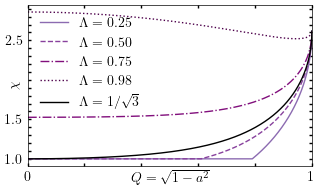

In [60]:
# Use sequential cmap
cmap = purple

fontsize = 10

# Take first 4 colors and reverse
cmap = cmap[:4][::-1]

names = ["col {}".format(i) for i in range(1, 20000)]
data = pd.read_csv("data/maximal_ibso_pro.dat", sep=",", names=names)
# Remove empty columns
data = data.dropna(axis=1, how='all')

replacement = {
    "{": "[",
    "}": "]",
    "\*\^": "e",
}

data = data.replace(replacement, regex=True)

# Transform elements to lists
data = data.applymap(lambda x: eval(x))

# Plot
fig, ax = plt.subplots(figsize=size_golden)
fig.patch.set_facecolor("white")
for i in range(0, 9):
    try:
        inc = data.iloc[i].apply(lambda x: x[0])[0]
        compare = np.sqrt(1/3)
        xlist = data.iloc[i].apply(lambda x: x[1])
        ylist = data.iloc[i].apply(lambda x: x[2])
        
        # Replace zero with NaN
        ylist = np.where(ylist == 0, np.nan, ylist)
        xlist = np.where(xlist == 0, np.nan, xlist)

        if compare*0.99 < inc < compare*1.01:
            ax.plot(xlist, ylist, label="$\Lambda = 1/\\sqrt{3}$", color="black")
            pass
        else:
            ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])
    except:
        pass
# Set log scale

ax.set_xlabel(r"$Q = \sqrt{1 - a^{2}}$", fontsize=fontsize)
ax.set_ylabel(r"$\chi$", fontsize=fontsize)

# Custom x-label position
ax.xaxis.set_label_coords(0.5, -0.025)
# Custom y-label position
ax.yaxis.set_label_coords(-0.025, 0.5)

# Set tick parameters
ax.tick_params("x", which="major", length=2, width=1, labelsize=fontsize)
ax.tick_params("x", which="minor", length=2, width=1, labelsize=fontsize)
ax.tick_params("y", which="major", length=2, width=1, labelsize=fontsize)
ax.tick_params("y", which="minor", length=2, width=1, labelsize=fontsize)


# ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Set plot range
ax.set_xlim(0, 1)

# Legend
# Custom position for different index
# if index == 0:
#     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.845))
# elif index == 2:
#     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.55))
# elif index == 3:
#     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.5))
# else:
#     ax.legend(fontsize=fontsize)

# Draw reference line and label values
# if index == 0:
#     ax.axhline(y=-0.180, color="grey", linestyle="--", linewidth=0.5)
#     ax.text(0.5, -0.180, "-0.180", 
#             fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")
# elif index == 2:
#     ax.axhline(y=0.0344, color="grey", linestyle="--", linewidth=0.5)
#     ax.text(0.5, 0.0344, "0.034", 
#             fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")
# elif index == 3:
#     ax.axhline(y=0.236, color="grey", linestyle="--", linewidth=0.5)
#     ax.text(0.5, 0.236, "0.236", 
#             fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")

# Only show first and last x-ticks
old_ticks = ax.get_xticks()
ax.set_xticks([old_ticks[0], old_ticks[-1]])
# Remove central y-ticks
old_ticks = ax.get_yticks()
central_index = len(old_ticks)//2 if len(old_ticks) != 2 else None
if central_index:
    ax.get_yticklabels()[central_index].set_visible(False)

plt.tight_layout()
plt.legend(fontsize=fontsize, loc="upper left")


plt.savefig("IBSO_maximal_pro.png", dpi=1000)

plt.show()

C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_30188\481852945.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_30188\481852945.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = data.iloc[i].apply(lambda x: x[0])[0]
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_30188\481852945.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])


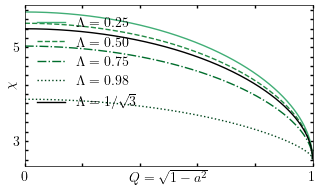

In [61]:
# Use sequential cmap
cmap = green

fontsize = 10

# Take first 4 colors and reverse
cmap = cmap[:4][::-1]

names = ["col {}".format(i) for i in range(1, 20000)]
data = pd.read_csv("data/maximal_ibso_ret.dat", sep=",", names=names)
# Remove empty columns
data = data.dropna(axis=1, how='all')

replacement = {
    "{": "[",
    "}": "]",
    "\*\^": "e",
}

data = data.replace(replacement, regex=True)

# Transform elements to lists
data = data.applymap(lambda x: eval(x))

# Plot
fig, ax = plt.subplots(figsize=size_golden)
fig.patch.set_facecolor("white")
for i in range(0, 9):
    try:
        inc = data.iloc[i].apply(lambda x: x[0])[0]
        compare = np.sqrt(1/3)
        xlist = data.iloc[i].apply(lambda x: x[1])
        ylist = data.iloc[i].apply(lambda x: x[2])
        
        # Replace zero with NaN
        ylist = np.where(ylist == 0, np.nan, ylist)
        xlist = np.where(xlist == 0, np.nan, xlist)

        if compare*0.99 < inc < compare*1.01:
            ax.plot(xlist, ylist, label="$\Lambda = 1/\\sqrt{3}$", color="black")
            pass
        else:
            ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])
    except:
        pass
# Set log scale

ax.set_xlabel(r"$Q = \sqrt{1 - a^{2}}$", fontsize=fontsize)
ax.set_ylabel(r"$\chi$", fontsize=fontsize)

# Custom x-label position
ax.xaxis.set_label_coords(0.5, -0.025)
# Custom y-label position
ax.yaxis.set_label_coords(-0.025, 0.5)

# Set tick parameters
ax.tick_params("x", which="major", length=2, width=1, labelsize=fontsize)
ax.tick_params("x", which="minor", length=2, width=1, labelsize=fontsize)
ax.tick_params("y", which="major", length=2, width=1, labelsize=fontsize)
ax.tick_params("y", which="minor", length=2, width=1, labelsize=fontsize)


# ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Set plot range
ax.set_xlim(0, 1)

# Legend
# Custom position for different index
# if index == 0:
#     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.845))
# elif index == 2:
#     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.55))
# elif index == 3:
#     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.5))
# else:
#     ax.legend(fontsize=fontsize)

# Draw reference line and label values
# if index == 0:
#     ax.axhline(y=-0.180, color="grey", linestyle="--", linewidth=0.5)
#     ax.text(0.5, -0.180, "-0.180", 
#             fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")
# elif index == 2:
#     ax.axhline(y=0.0344, color="grey", linestyle="--", linewidth=0.5)
#     ax.text(0.5, 0.0344, "0.034", 
#             fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")
# elif index == 3:
#     ax.axhline(y=0.236, color="grey", linestyle="--", linewidth=0.5)
#     ax.text(0.5, 0.236, "0.236", 
#             fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")

# Only show first and last x-ticks
old_ticks = ax.get_xticks()
ax.set_xticks([old_ticks[0], old_ticks[-1]])
# Remove central y-ticks
old_ticks = ax.get_yticks()
central_index = len(old_ticks)//2 if len(old_ticks) != 2 else None
if central_index:
    ax.get_yticklabels()[central_index].set_visible(False)

plt.tight_layout()
plt.legend(fontsize=fontsize, loc="upper left")


plt.savefig("IBSO_maximal_ret.png", dpi=1000)

plt.show()

## IBSO eigenvalue plots

C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3222480123.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3222480123.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = data.iloc[i].apply(lambda x: x[0])[0]
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3222480123.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])


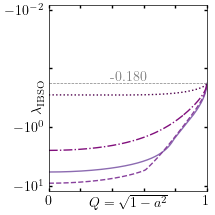

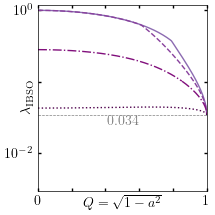

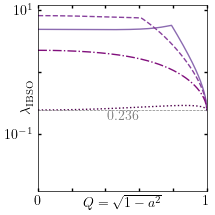

In [22]:
# Use sequential cmap
cmap = purple

fontsize = 10

# Take first 4 colors and reverse
cmap = cmap[:4][::-1]

names = ["col {}".format(i) for i in range(1, 20000)]
data = pd.read_csv("data/maximal_pro.txt", sep=",", names=names)
# Remove empty columns
data = data.dropna(axis=1, how='all')

replacement = {
    "{": "[",
    "}": "]",
    "\*\^": "e",
}

data = data.replace(replacement, regex=True)

# Transform elements to lists
data = data.applymap(lambda x: eval(x))

for index in [0, 2, 3]:

    # Plot
    fig, ax = plt.subplots(figsize=size_twocolbythree)
    fig.patch.set_facecolor("white")
    for i in range(0, 9):
        try:
            inc = data.iloc[i].apply(lambda x: x[0])[0]
            compare = np.sqrt(1/3)
            xlist = data.iloc[i].apply(lambda x: x[1])
            ylist = data.iloc[i].apply(lambda x: x[2][index])

            # Remove last element
            xlist = xlist[:-1]
            ylist = ylist[:-1]
            
            # Add final data point
            if index == 0:
                xlist = np.append(xlist, 1)
                ylist = np.append(ylist, -0.180)
            elif index == 2:
                xlist = np.append(xlist, 1)
                ylist = np.append(ylist, 0.0344)
            elif index == 3:
                xlist = np.append(xlist, 1)
                ylist = np.append(ylist, 0.236)
            else:
                pass
            
            # Replace zero with NaN
            ylist = np.where(ylist == 0, np.nan, ylist)
            xlist = np.where(xlist == 0, np.nan, xlist)

            if compare*0.99 < inc < compare*1.01:
                # ax.plot(xlist, ylist, label="$\Lambda = 1/\\sqrt{3}$", color="black")
                pass
            else:
                ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])
        except:
            pass
    # Set log scale
    ax.set_yscale("symlog", linthresh=1e-3)

    ax.set_xlabel(r"$Q = \sqrt{1 - a^{2}}$", fontsize=fontsize)
    ax.set_ylabel(r"$\lambda_{\text{IBSO}}$", fontsize=fontsize)
    
    # Custom x-label position
    ax.xaxis.set_label_coords(0.5, -0.025)
    # Custom y-label position
    ax.yaxis.set_label_coords(-0.025, 0.5)
    
    # Set tick parameters
    ax.tick_params("x", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("x", which="minor", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="minor", length=2, width=1, labelsize=fontsize)
    
    
    # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    # Set plot range
    ax.set_xlim(0, 1)

    # Legend
    # Custom position for different index
    # if index == 0:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.845))
    # elif index == 2:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.55))
    # elif index == 3:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.5))
    # else:
    #     ax.legend(fontsize=fontsize)
    
    # Draw reference line and label values
    if index == 0:
        ax.axhline(y=-0.180, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, -0.180, "-0.180", 
                fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")
    elif index == 2:
        ax.axhline(y=0.0344, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, 0.0344, "0.034", 
                fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")
    elif index == 3:
        ax.axhline(y=0.236, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, 0.236, "0.236", 
                fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")
    
    # Set custom ylims
    if index == 0:
        ax.set_ylim(-10*1.2, -0.01/1.2)
    elif index == 2:
        ax.set_ylim(10e-4*3, 1*1.2)
    elif index == 3:
        ax.set_ylim(10e-3*1.2, 10*1.2)
    else:
        pass
    
    # Only show first and last x-ticks
    old_ticks = ax.get_xticks()
    ax.set_xticks([old_ticks[0], old_ticks[-1]])
    # Remove central y-ticks
    old_ticks = ax.get_yticks()
    central_index = len(old_ticks)//2 if len(old_ticks) != 2 else None
    if central_index:
        ax.get_yticklabels()[central_index].set_visible(False)

    plt.tight_layout()

    plt.savefig("tidal_eigenvalue_maximal_pro_{}.png".format(index), dpi=1000)

    plt.show()

C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\4191530234.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\4191530234.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = data.iloc[i].apply(lambda x: x[0])[0]
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\4191530234.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])


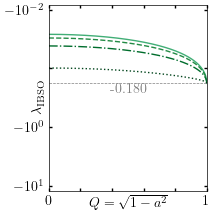

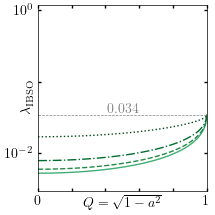

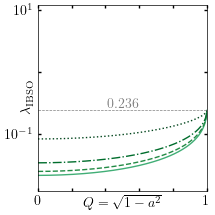

In [21]:
# Use sequential cmap
cmap = green

fontsize = 10

# Take first 4 colors and reverse
cmap = cmap[:4][::-1]

names = ["col {}".format(i) for i in range(1, 20000)]
data = pd.read_csv("data/maximal_ret.txt", sep=",", names=names)
# Remove empty columns
data = data.dropna(axis=1, how='all')

replacement = {
    "{": "[",
    "}": "]",
    "\*\^": "e",
}

data = data.replace(replacement, regex=True)

# Transform elements to lists
data = data.applymap(lambda x: eval(x))

for index in [0, 2, 3]:

    # Plot
    fig, ax = plt.subplots(figsize=size_twocolbythree)
    fig.patch.set_facecolor("white")
    for i in range(0, 9):
        try:
            inc = data.iloc[i].apply(lambda x: x[0])[0]
            compare = np.sqrt(1/3)
            xlist = data.iloc[i].apply(lambda x: x[1])
            ylist = data.iloc[i].apply(lambda x: x[2][index])

            # Remove last element
            xlist = xlist[:-1]
            ylist = ylist[:-1]
            
            # Add final data point
            if index == 0:
                xlist = np.append(xlist, 1)
                ylist = np.append(ylist, -0.180)
            elif index == 2:
                xlist = np.append(xlist, 1)
                ylist = np.append(ylist, 0.0344)
            elif index == 3:
                xlist = np.append(xlist, 1)
                ylist = np.append(ylist, 0.236)
            else:
                pass
            
            # Replace zero with NaN
            ylist = np.where(ylist == 0, np.nan, ylist)
            xlist = np.where(xlist == 0, np.nan, xlist)

            if compare*0.99 < inc < compare*1.01:
                # ax.plot(xlist, ylist, label="$\Lambda = 1/\\sqrt{3}$", color="black")
                pass
            else:
                ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i])
        except:
            pass
    # Set log scale
    ax.set_yscale("symlog", linthresh=1e-3)

    ax.set_xlabel(r"$Q = \sqrt{1 - a^{2}}$", fontsize=fontsize)
    ax.set_ylabel(r"$\lambda_{\text{IBSO}}$", fontsize=fontsize)
    
    # Custom x-label position
    ax.xaxis.set_label_coords(0.5, -0.025)
    # Custom y-label position
    ax.yaxis.set_label_coords(-0.025, 0.5)
    
    # Set tick parameters
    ax.tick_params("x", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("x", which="minor", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="minor", length=2, width=1, labelsize=fontsize)
    
    
    # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    
    # Draw reference line and label values
    if index == 0:
        ax.axhline(y=-0.180, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, -0.180, "-0.180", 
                fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")
    elif index == 2:
        ax.axhline(y=0.0344, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, 0.0344, "0.034", 
                fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")
    elif index == 3:
        ax.axhline(y=0.236, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, 0.236, "0.236", 
                fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")

    # Legend
    # Custom position for different index
    # if index == 0:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.845))
    # elif index == 2:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.55))
    # elif index == 3:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.5))
    # else:
    #     ax.legend(fontsize=fontsize)
    
    # Set plot range
    ax.set_xlim(0, 1)

    # Set custom ylims
    if index == 0:
        ax.set_ylim(-10*1.2, -0.01/1.2)
    elif index == 2:
        ax.set_ylim(10e-4*3, 1*1.2)
    elif index == 3:
        ax.set_ylim(10e-3*1.2, 10*1.2)
    else:
        pass
    
    # Only show first and last x-ticks
    old_ticks = ax.get_xticks()
    ax.set_xticks([old_ticks[0], old_ticks[-1]])
    # Remove central y-ticks
    old_ticks = ax.get_yticks()
    central_index = len(old_ticks)//2
    ax.get_yticklabels()[central_index].set_visible(False)

    plt.tight_layout()

    plt.savefig("tidal_eigenvalue_maximal_ret_{}.png".format(index), dpi=1000)

    plt.show()

combine plots

C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3787510210.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_pro = data_pro.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3787510210.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_ret = data_ret.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3787510210.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = data.iloc[i].apply(lambda x: x[0])[0]
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_22140\3787510210.py:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame 

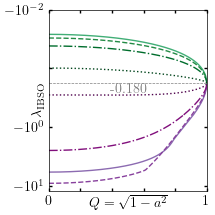

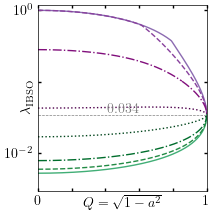

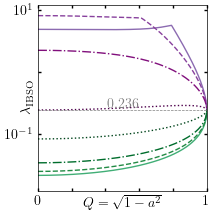

In [13]:
# Use sequential cmap
cmap_pro = purple[:4][::-1]
cmap_ret = green[:4][::-1]

fontsize = 10

names = ["col {}".format(i) for i in range(1, 20000)]
data_pro = pd.read_csv("data/maximal_pro.txt", sep=",", names=names)
# Remove empty columns
data_pro = data_pro.dropna(axis=1, how='all')

data_ret = pd.read_csv("data/maximal_ret.txt", sep=",", names=names)
# Remove empty columns
data_ret = data_ret.dropna(axis=1, how='all')

replacement = {
    "{": "[",
    "}": "]",
    "\*\^": "e",
}

data_pro = data_pro.replace(replacement, regex=True)
data_ret = data_ret.replace(replacement, regex=True)

# Transform elements to lists
data_pro = data_pro.applymap(lambda x: eval(x))
data_ret = data_ret.applymap(lambda x: eval(x))
data_list = [data_pro, data_ret]

style_list = ['-', '--', '-.', ':']

for index in [0, 2, 3]:
    # Plot
    fig, ax = plt.subplots(figsize=size_twocolbythree)
    fig.patch.set_facecolor("white")
    for counter in range(2):
        data = data_list[counter]
        if counter == 0:
            cmap = cmap_pro
        else:
            cmap = cmap_ret
        for i in range(0, 9):
            try:
                inc = data.iloc[i].apply(lambda x: x[0])[0]
                compare = np.sqrt(1/3)
                xlist = data.iloc[i].apply(lambda x: x[1])
                ylist = data.iloc[i].apply(lambda x: x[2][index])

                # Remove last element
                xlist = xlist[:-1]
                ylist = ylist[:-1]
                
                # Add final data point
                if index == 0:
                    xlist = np.append(xlist, 1)
                    ylist = np.append(ylist, -0.180)
                elif index == 2:
                    xlist = np.append(xlist, 1)
                    ylist = np.append(ylist, 0.0344)
                elif index == 3:
                    xlist = np.append(xlist, 1)
                    ylist = np.append(ylist, 0.236)
                else:
                    pass
                
                # Replace zero with NaN
                ylist = np.where(ylist == 0, np.nan, ylist)
                xlist = np.where(xlist == 0, np.nan, xlist)

                if compare*0.99 < inc < compare*1.01:
                    # ax.plot(xlist, ylist, label="$\Lambda = 1/\\sqrt{3}$", color="black")
                    pass
                else:
                    ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(data.iloc[i].apply(lambda x: x[0])[0]), color=cmap[i], linestyle=style_list[i])
            except:
                pass
    # Set log scale
    ax.set_yscale("symlog", linthresh=1e-3)

    ax.set_xlabel(r"$Q = \sqrt{1 - a^{2}}$", fontsize=fontsize)
    ax.set_ylabel(r"$\lambda_{\text{IBSO}}$", fontsize=fontsize)
    
    # Custom x-label position
    ax.xaxis.set_label_coords(0.5, -0.025)
    # Custom y-label position
    ax.yaxis.set_label_coords(-0.025, 0.5)
    
    # Set tick parameters
    ax.tick_params("x", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("x", which="minor", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="minor", length=2, width=1, labelsize=fontsize)
    
    
    # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    
    # Draw reference line and label values
    if index == 0:
        ax.axhline(y=-0.180, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, -0.180, "-0.180", 
                fontsize=fontsize, color="grey", verticalalignment="top", horizontalalignment="center")
    elif index == 2:
        ax.axhline(y=0.0344, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, 0.0344, "0.034", 
                fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")
    elif index == 3:
        ax.axhline(y=0.236, color="grey", linestyle="--", linewidth=0.5)
        ax.text(0.5, 0.236, "0.236", 
                fontsize=fontsize, color="grey", verticalalignment="bottom", horizontalalignment="center")

    # Legend
    # Custom position for different index
    # if index == 0:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.845))
    # elif index == 2:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.55))
    # elif index == 3:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.5))
    # else:
    #     ax.legend(fontsize=fontsize)
    
    # Set plot range
    ax.set_xlim(0, 1)

    # Set custom ylims
    if index == 0:
        ax.set_ylim(-10*1.2, -0.01)
    elif index == 2:
        ax.set_ylim(10e-4*3, 1*1.2)
    elif index == 3:
        ax.set_ylim(10e-3*1.2, 10*1.2)
    else:
        pass
    
    # Only show first and last x-ticks
    old_ticks = ax.get_xticks()
    ax.set_xticks([old_ticks[0], old_ticks[-1]])
    # Remove central y-ticks
    old_ticks = ax.get_yticks()
    central_index = len(old_ticks)//2
    ax.get_yticklabels()[central_index].set_visible(False)

    plt.tight_layout()

    plt.savefig("tidal_eigenvalue_maximal_{}.png".format(index), dpi=1000)

    plt.show()

single angle combined

C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_13628\2754720057.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_pro = data_pro.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_13628\2754720057.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_ret = data_ret.applymap(lambda x: eval(x))
C:\Users\WalkerXin\AppData\Local\Temp\ipykernel_13628\2754720057.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inc = data.iloc[i].apply(lambda x: x[0])[0]


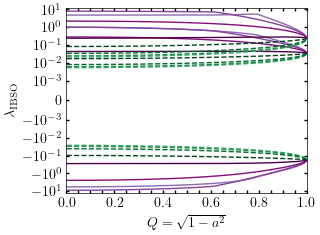

In [24]:
# Use sequential cmap
cmap_pro = purple[:4][::-1]
cmap_ret = green[:4][::-1]

fontsize = 10

names = ["col {}".format(i) for i in range(1, 20000)]
data_pro = pd.read_csv("data/maximal_pro.txt", sep=",", names=names)
# Remove empty columns
data_pro = data_pro.dropna(axis=1, how='all')

data_ret = pd.read_csv("data/maximal_ret.txt", sep=",", names=names)
# Remove empty columns
data_ret = data_ret.dropna(axis=1, how='all')

replacement = {
    "{": "[",
    "}": "]",
    "\*\^": "e",
}

data_pro = data_pro.replace(replacement, regex=True)
data_ret = data_ret.replace(replacement, regex=True)

# Transform elements to lists
data_pro = data_pro.applymap(lambda x: eval(x))
data_ret = data_ret.applymap(lambda x: eval(x))
data_list = [data_pro, data_ret]

style_list = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=size_fourbythree)
fig.patch.set_facecolor("white")

for index in [0, 2, 3]:
    # Plot
    for counter in range(2):
        data = data_list[counter]
        if counter == 0:
            cmap = cmap_pro
        else:
            cmap = cmap_ret
        for i in range(0, 9):
            try:
                inc = data.iloc[i].apply(lambda x: x[0])[0]
                compare = 0.5
                xlist = data.iloc[i].apply(lambda x: x[1])
                ylist = data.iloc[i].apply(lambda x: x[2][index])

                # Remove last element
                xlist = xlist[:-1]
                ylist = ylist[:-1]
                
                # Add final data point
                if index == 0:
                    xlist = np.append(xlist, 1)
                    ylist = np.append(ylist, -0.180)
                elif index == 2:
                    xlist = np.append(xlist, 1)
                    ylist = np.append(ylist, 0.0344)
                elif index == 3:
                    xlist = np.append(xlist, 1)
                    ylist = np.append(ylist, 0.236)
                else:
                    pass
                
                # Replace zero with NaN
                ylist = np.where(ylist == 0, np.nan, ylist)
                xlist = np.where(xlist == 0, np.nan, xlist)

                if compare*0.99 < inc < compare*1.01:
                    if counter == 0:
                        temp = '-'
                    else:
                        temp = '--'
                    ax.plot(xlist, ylist, label="$\Lambda = {:.2f}$".format(inc), color=cmap[i], linestyle=temp)
                else:
                    pass
            except:
                pass
    # Set log scale
    ax.set_yscale("symlog", linthresh=1e-3)

    ax.set_xlabel(r"$Q = \sqrt{1 - a^{2}}$", fontsize=fontsize)
    ax.set_ylabel(r"$\lambda_{\text{IBSO}}$", fontsize=fontsize)
    
    # Set tick parameters
    ax.tick_params("x", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("x", which="minor", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="major", length=2, width=1, labelsize=fontsize)
    ax.tick_params("y", which="minor", length=2, width=1, labelsize=fontsize)
    
    
    # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    # Legend
    # Custom position for different index
    # if index == 0:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.845))
    # elif index == 2:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.55))
    # elif index == 3:
    #     ax.legend(fontsize=fontsize, loc="upper left", bbox_to_anchor=(0.0, 0.5))
    # else:
    #     ax.legend(fontsize=fontsize)
    
    # Set plot range
    ax.set_xlim(0, 1)

    # Set custom ylims
    ax.set_ylim(-10*1.2, 10*1.2)
    
    # Only show first and last x-ticks
    # old_ticks = ax.get_xticks()
    # ax.set_xticks([old_ticks[0], old_ticks[-1]])
    # # Remove central y-ticks
    # old_ticks = ax.get_yticks()
    # central_index = len(old_ticks)//2
    # ax.get_yticklabels()[central_index].set_visible(False)

plt.tight_layout()

plt.savefig("tidal_eigenvalue_maximal_all.png", dpi=1000)

plt.show()

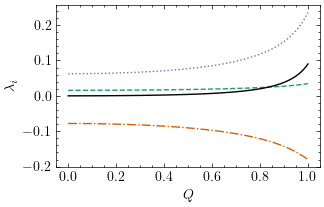

In [6]:
cmap = plt.get_cmap("Dark2")
fontsize = 10

names = ["Q","lambda_1","lambda_2","lambda_3","lambda_sum"]
data = pd.read_csv("data/eigenibso.dat", sep="	", names=names)

fig, ax = plt.subplots(figsize=size_golden)
ax.plot(data["Q"], data["lambda_1"], label=r"$\lambda_1$", color=cmap(0), linestyle="--")
ax.plot(data["Q"], data["lambda_2"], label=r"$\lambda_2$", color=cmap(1), linestyle="-.")
ax.plot(data["Q"], data["lambda_3"], label=r"$\lambda_3$", color=cmap(2), linestyle=":")
ax.plot(data["Q"], data["lambda_sum"], color="black", linestyle="-")

# Move x-label to top
# ax.xaxis.set_label_position("top")

# Move y-label to right
# ax.yaxis.set_label_position("right")

ax.set_xlabel(r"$Q$", fontsize=fontsize)
ax.set_ylabel(r"$\lambda_{i}$", fontsize=fontsize)
# ax.legend()
# plt.tight_layout()

plt.savefig("tidal_eigenvalue_RN.png", dpi=1000)

plt.show()

## Running C++ scripts

In [2]:
# Set parameters
params = give_params(
    spin = 0.5,
    charge = 0.5,
    lam = 0.5,
    x = 2.701418260779751,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)

# Create executable path = current directory + main
executable_path = os.path.join(os.getcwd(), "main.exe")

# Check if main.exe exists. If not, compile the main.cpp file
if not os.path.exists(executable_path):
    print("main.exe does not exist. Compiling main.cpp...")
    subprocess.run("g++ -g main.cpp -o main.exe -O3", shell=True)
    
command = command_generation(params, executable_path)
print("main.exe found. Running with command:", command)

# Run the command and print stdout
result = subprocess.run(command, stdout=subprocess.PIPE, shell=True)
print(result.stdout.decode("utf-8"))

NameError: name 'np' is not defined

## Plotting

4461


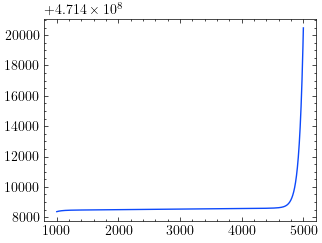

In [36]:

params = give_params(
    spin = 0.5,
    charge = 0.5,
    lam = 0.5,
    x = 2.701418260779751,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)
data = load_geodesic(give_filename(params, tidal=False))

print(
    check_mono_r(data['r'], threshold=0.05, window_size=100)
)

end = len(data['t'])

plt.plot(data.index[1000:5000], data['tau'][1000:5000])
# plt.yscale('log')
plt.show()

### Geodesic plot

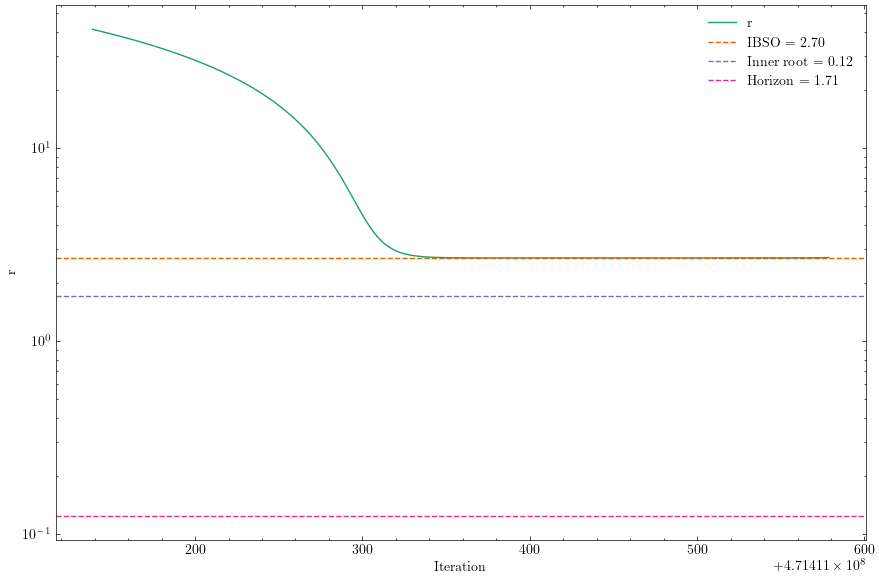

In [49]:
# Plot geodesic data
params = give_params(
    spin = 0.5,
    charge = 0.5,
    lam = 0.5,
    x = 2.701418260779751,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)

mono_end = check_mono_r(data['r'], threshold=0.01, window_size=100)
mono_end = int(mono_end*0.92) if mono_end else end

geodesic_plot(params, show=True, save=False, xaxis="t", range=[mono_end-3000, mono_end])

### Tidal plot

In [6]:
# manually check tidal data
tidal_data = load_tensor_cpp("/Users/walkerxin/Documents/Scripts/tidal_disruption/integrator_unified/data/eigensystem_a_0.50_Q_0.50_lambda_0.50_pro.dat")

start: 939
end: 3682


2

0.0

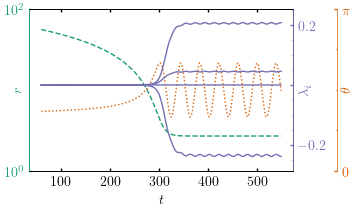

In [146]:
# Plot tidal data
params = give_params(
    spin = 0.5,
    charge = 0.5,
    lam = 0.5,
    x = 2.701418260779751,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)

data = load_geodesic(give_filename(params, tidal=False))
cmap = plt.get_cmap("Dark2")

start = find_start(data['r'], target=10**1.75)
end = check_r(data['r'], target=2.701418260779751*1.01, threshold=0.01)
end = int(end*0.9) if end else len(data['r'])

tidal_plot_alt(params, save=False, show=True, legend=False, dpi=1000, figsize=size_golden, fontsize=10, major_length=2, minor_length=1, plot_range=[start, end], custom_cmap=cmap)

xdata change: 30.0


2

0.0

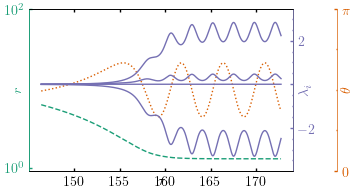

In [164]:
# Plot tidal data
params = give_params(
    spin = 0.99,
    charge = 0,
    lam = 0.5,
    x = 3.028130755578739,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)

tidal_plot_alt(params, save=False, show=True, legend=False, dpi=1000, figsize=size_golden, fontsize=10, major_length=2, minor_length=1, xaxis='tau', plot_range=[1200, 3022])

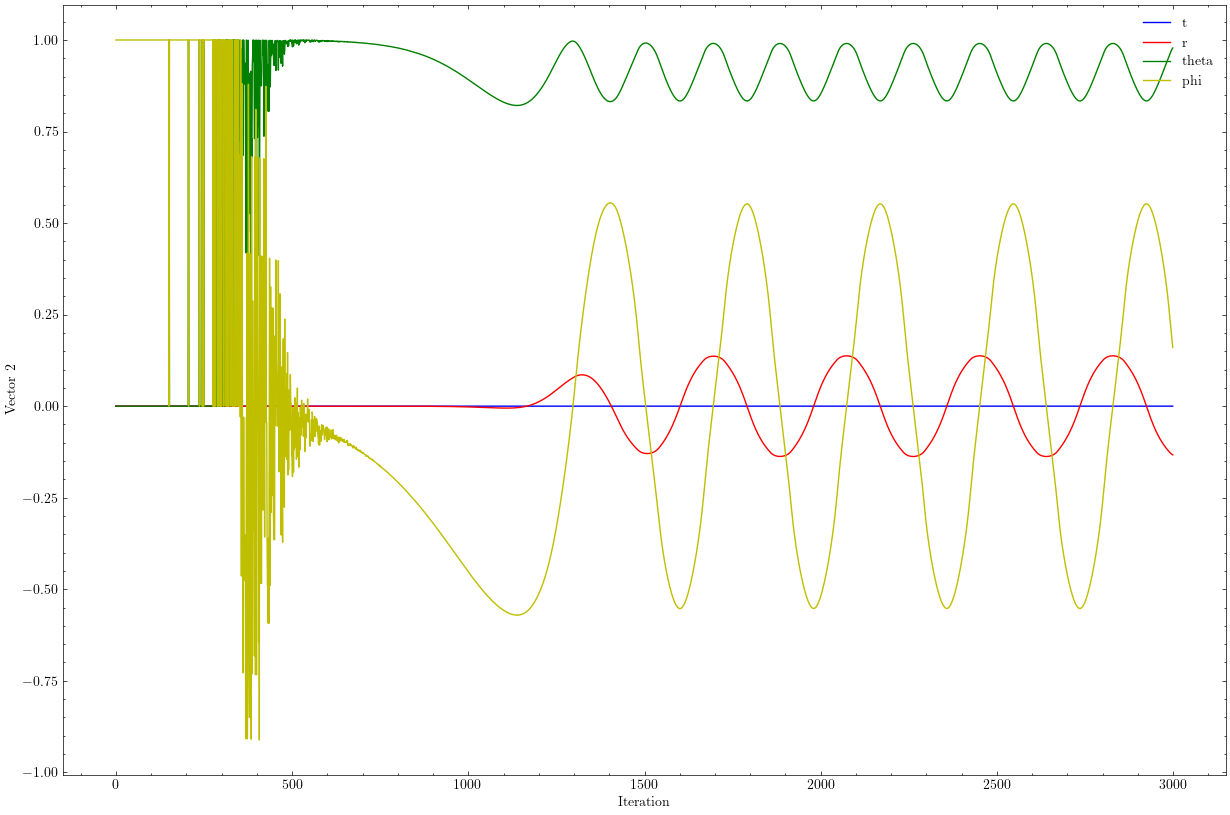

In [ ]:
params = give_params(
    spin = 0.5,
    charge = 0.5,
    lam = 0.5,
    x = 2.701418260779751,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)

filename = give_filename(params, tidal=True)
tidal_data = load_tensor_cpp(filename, cutoff=3000)

index_i = 0
index_f = 3000

# Plot evolution of an eigenvector, 4 components share the same axis
fig, ax1 = plt.subplots(figsize=(15, 10))
target_index = 2

# Set background colour to white
fig.patch.set_facecolor("white")

ax1.plot(
    tidal_data.index[index_i:index_f],
    tidal_data["vector_{}".format(target_index)][index_i:index_f].apply(lambda x: x[0]),
    "b-",
)
ax1.plot(
    tidal_data.index[index_i:index_f],
    tidal_data["vector_{}".format(target_index)][index_i:index_f].apply(lambda x: x[1]),
    "r-",
)
ax1.plot(
    tidal_data.index[index_i:index_f],
    tidal_data["vector_{}".format(target_index)][index_i:index_f].apply(lambda x: x[2]),
    "g-",
)
ax1.plot(
    tidal_data.index[index_i:index_f],
    tidal_data["vector_{}".format(target_index)][index_i:index_f].apply(lambda x: x[3]),
    "y-",
)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Vector {}".format(target_index))
ax1.legend(["t", "r", "theta", "phi"], loc="upper right")


plt.show()

In [ ]:
# 3D plot
%matplotlib tk

params = give_params(
    spin = 0.5,
    charge = 0.5,
    lam = 0.1,
    x = 2.588913507250797,
    scale = 1,
    eigenswitch = 1,
    total_steps = 20000,
    tidal_reference=None
)

filename = give_filename(params, tidal=False)
data = load_geodesic(filename, cutoff=4000)

plotrange = 3000
zoom = 1.5
fig = plt.figure(figsize=size_square)
ax = fig.add_subplot(111, projection='3d')
ax.plot(data['x'][:plotrange], data['y'][:plotrange], data['z'][:plotrange])

# Draw a semi-transparent sphere of radius x
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = params["x"]
y = x * np.outer(np.cos(u), np.sin(v))
z = x * np.outer(np.sin(u), np.sin(v))
w = x * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(y, z, w, color='b', alpha=0.1)

# Remove axis labels and numbers
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_zticklabels([])

# Set camera angle
ax.view_init(elev=2, azim=225)

# Set equal aspect ratio
ax.set_box_aspect([1,1,1])

# Centre around r=x, set origin to be at the centre
x = params["x"]
ax.set_xlim(-zoom*x, zoom*x)
ax.set_ylim(-zoom*x, zoom*x)
ax.set_zlim(-zoom*x, zoom*x)

plt.tight_layout()

plt.savefig("IBSO_3D_a_{:.2f}_Q_{:.2f}_lambda_{:.2f}.png".format(params["spin"], params["charge"], params["lam"]), dpi=1000)

plt.show()

## Bulk Saving and Plotting

### Kerr

2

0.0

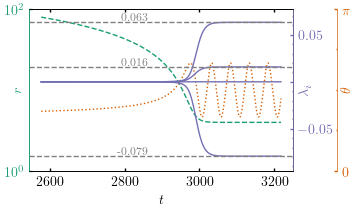

3

0.0

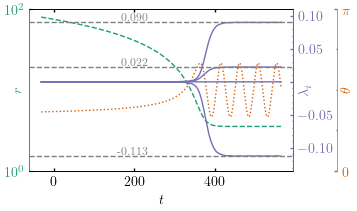

3

0.0

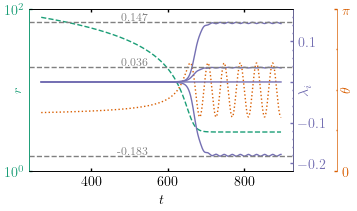

3

0.0

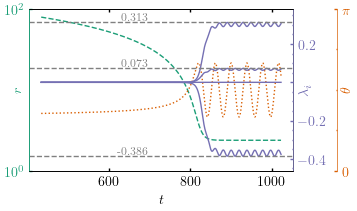

2

0.0

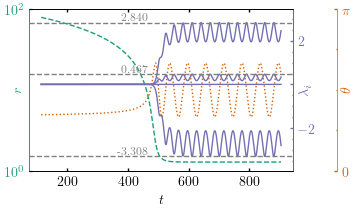

In [167]:

# Bulk processing for Q = 0
spinlist = np.array([0.01, 0.25, 0.5, 0.75, 0.99])
lamlist = np.array([0.5])
chargelist = np.array([0.0])
xlist = np.array(
    [
        3.982648092141904,
        3.544689430531115,
        3.028130755578739,
        2.394802473518877,
        1.288570297303052
    ]
)
referencelist = np.array(
    [
        [-0.0791509,0.0158301,0.0633208],
        [-0.112598,0.0224525,0.0901456],
        [-0.183038,0.0360144,0.147023],
        [-0.386012,0.07281,0.313202],
        [-3.30787,0.467386,2.84048]
    ]
)
plot_range_list = [
    'auto',
    'auto',
    'auto',
    'auto',
    'auto'
]

executable_path = os.path.join(os.getcwd(), "main.exe")

for i in range(len(spinlist)):
    params = give_params(
        spin = spinlist[i],
        charge = chargelist[0],
        lam = lamlist[0],
        x = xlist[i],
        scale = 1,
        eigenswitch = 1,
        total_steps = 20000,
        tidal_reference=referencelist[i]
    )
    command = command_generation(params, executable_path) 
    # print("main.exe found. Running with command:", command)
    result = subprocess.run(command, stdout=subprocess.PIPE, shell=True)

    # print(result.stdout.decode("utf-8"))
    
    # tidal_plot(params, save=True, show=True, legend=False, dpi=1000, figsize=size_fourbythree, fontsize=10, major_length=2, minor_length=1, cutoff=3000)
    cmap = plt.get_cmap("Dark2")
    
    data = load_geodesic(give_filename(params, tidal=False))

    start = find_start(data['r'], target=10**1.9)
    end = check_r(data['r'], target=xlist[i]*1.01, threshold=0.01)
    end = int(end*0.85) if end else len(data['r'])

    tidal_plot_alt(params, save=True, show=True, legend=False, dpi=1000, figsize=size_golden, fontsize=10, major_length=2, minor_length=1, plot_range=[start, end], custom_cmap=cmap)

### Kerr-Newman

main.exe found. Running with command: /Users/walkerxin/Documents/Scripts/tidal_disruption/integrator_unified/main.exe 0.5 0.1 0.5 3.016106238733084 20000 1 1


3

0.0

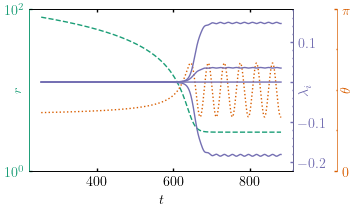

main.exe found. Running with command: /Users/walkerxin/Documents/Scripts/tidal_disruption/integrator_unified/main.exe 0.5 0.25 0.5 2.951745871586405 20000 1 1


3

0.0

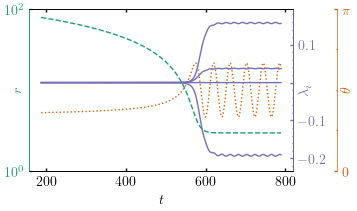

main.exe found. Running with command: /Users/walkerxin/Documents/Scripts/tidal_disruption/integrator_unified/main.exe 0.5 0.5 0.5 2.701418260779751 20000 1 1


2

0.0

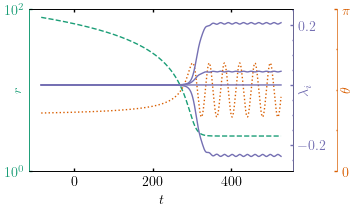

main.exe found. Running with command: /Users/walkerxin/Documents/Scripts/tidal_disruption/integrator_unified/main.exe 0.5 0.75 0.5 2.154901497944337 20000 1 1


2

0.0

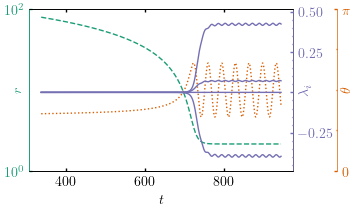

main.exe found. Running with command: /Users/walkerxin/Documents/Scripts/tidal_disruption/integrator_unified/main.exe 0.5 0.85 0.5 1.656498806818928 20000 1 1


2

0.0

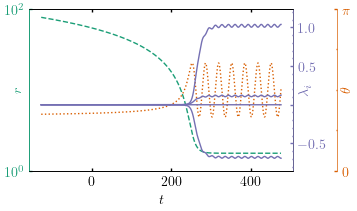

In [168]:
# Bulk processing for a = 0.5, Q != 0
spinlist = np.array([0.5])
lamlist = np.array([0.5])
chargelist = np.array([0.1, 0.25, 0.5, 0.75, 0.85])
xlist = np.array(
    [
        3.016106238733084,
        2.951745871586405,
        2.701418260779751,
        2.154901497944337,
        1.656498806818928
    ]
)

executable_path = os.path.join(os.getcwd(), "main.exe")

for i in range(len(chargelist)):
    params = give_params(
        spin = spinlist[0],
        charge = chargelist[i],
        lam = lamlist[0],
        x = xlist[i],
        scale = 1,
        eigenswitch = 1,
        total_steps = 20000,
        tidal_reference=None
    )
    command = command_generation(params, executable_path) 
    # print("main.exe found. Running with command:", command)
    result = subprocess.run(command, stdout=subprocess.PIPE, shell=True)

    data = load_geodesic(give_filename(params, tidal=False))

    start = find_start(data['r'], target=10**1.9)
    end = check_r(data['r'], target=xlist[i]*1.01, threshold=0.01)
    end = int(end*0.85) if end else len(data['r'])

    tidal_plot_alt(params, save=True, show=True, legend=False, dpi=1000, figsize=size_golden, fontsize=10, major_length=2, minor_length=1, plot_range=[start, end], custom_cmap=cmap)

In [171]:
# Move newly created plots with names eigensystem*.png to folder plots
import shutil
import glob
asset_folder = "../documentation/asset"
if not os.path.exists(asset_folder):
    os.makedirs(asset_folder)
    
# Overwrite existing files
for file in glob.glob("data/eigensystem_*.png"):
    filename = os.path.basename(file)
    shutil.move(file, os.path.join(asset_folder, filename))

In [38]:
def sum(r, chi, Q, a, lz, k):
    sigma = r**2 + a**2*chi**2
    temp = a**2*(2 - chi**2 - 2)  + 2*k + r**2
    return (Q**2*temp)/(sigma**3)

In [39]:
# Create column of tidal value sum in tidal_data
tidal_data["value_sum"] = tidal_data[["value_0", "value_1", "value_2", "value_3"]].sum(axis=1)

In [40]:
# Compute k = (lz - a*ep)^2 + lz^2*lam^2/(1 - lam^2)
k = (params["lz"] - params["spin"]*1)**2 + params["lz"]**2*params["lam"]**2/(1 - params["lam"]**2)
display(k)

8.32066554597877

In [41]:
# Calculate predicted sum
data["predicted_sum"] = sum(data["r"], data["chi"], params["charge"], params["spin"], params["lz"], k)

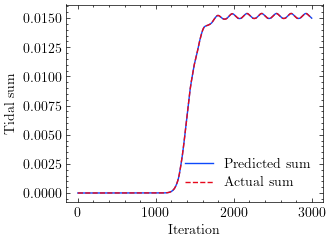

In [42]:
# Compare predicted sum with actual sum
plt.plot(data.index, data["predicted_sum"], label="Predicted sum")
plt.plot(tidal_data.index, tidal_data["value_sum"], label="Actual sum")

plt.xlabel("Iteration")
plt.ylabel("Tidal sum")
plt.legend()
plt.tight_layout()

plt.show()